<div style="background-color:#1F3864; padding:25px; border-radius:8px;">
<h1 style="color:white; text-align:center; margin:0;">🌍 Global Trade Disruption & Commodity Price Prediction</h1>
<p style="color:#D9E2F3; text-align:center; margin-top:10px; font-size:15px;">
Predicting commodity price movements from real-world supply chain disruption signals -
built entirely on live API data (FRED, GDELT, UN Comtrade, World Bank)
</p>
</div>

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import requests
import yfinance as yf
import time

## Notebook Overview

This notebook builds a dataset and model to predict commodity price movements —
starting with WTI crude oil — using real-world supply chain disruption signals
sourced directly from public APIs, rather than a synthetic dataset.

**Data sources:**
- **FRED API** — commodity prices (oil WTI, oil Brent, natural gas, wheat, corn, gold, aluminum, iron ore)
- **GDELT** — geopolitical event intensity and global news coverage volume
- **UN Comtrade** — bilateral trade volume between countries
- **World Bank** — country-level logistics performance and economic context

**Target variable:**
Percentage change in WTI crude oil price over a forward window (e.g. 30 days),
predicted from current disruption signals. Predicting the *change* rather than
the raw price level avoids the model simply learning long-term inflation trends,
and instead focuses on how disruption events actually move prices — the same
approach used in the crash prediction project's 63-day-forward target.

**Major real-world events this data is expected to capture:**
COVID-19 Supply Chain Shock (2020), Russia-Ukraine Conflict (2022),
Red Sea Shipping Crisis (2024), Strait of Hormuz Disruption (2026).

<div style="background-color:#EDCC80; padding:15px; border-radius:8px;">
<h2 style="color:#1F3864; text-align:center; margin:0;">1. Create the Data</h2>
</div>

<div style="background-color:#EDEAE5; padding:10px 15px; border-radius:6px;">
<h3 style="color:#1F3864; text-align:center; margin:0;">1.1 Commodities</h3>
</div>

In [2]:
api_key = "a3b1c076b07a348c2f9a24b0799e53e2"

In [3]:
start_date = "2000-01-01"

In [4]:
commodities = {
    "oil_wti": "DCOILWTICO",
    "oil_brent": "DCOILBRENTEU",
    "natural_gas": "DHHNGSP",
    "wheat": "PWHEAMTUSDM",
    "corn": "PMAIZMTUSDM",
    "aluminum": "PALUMUSDM",
    "iron_ore": "PIORECRUSDM"}

In [5]:
def get_commodity_prices(commodities: dict, start_date: str) -> None:
    for name, series_id in commodities.items():
        url = f"https://api.stlouisfed.org/fred/series/observations?series_id={series_id}&observation_start={start_date}&api_key={api_key}&file_type=json"
        response = requests.get(url)
        try:
            data = response.json()
        except ValueError:
            print(f"FAILED: {name} ({series_id}) — empty or invalid response, status {response.status_code}")
            continue
        if "observations" not in data:
            print(f"FAILED: {name} ({series_id}) — {data.get('error_message', 'unknown error')}")
            continue
        df = pd.DataFrame(data["observations"])
        df = df[["date", "value"]]
        df.to_csv(f"data/{name}.csv", index=False)
        print(f"Saved {len(df)} rows to data/{name}.csv")
        time.sleep(0.5)

In [6]:
get_commodity_prices(commodities,start_date)

Saved 6931 rows to data/oil_wti.csv
Saved 6931 rows to data/oil_brent.csv
Saved 6931 rows to data/natural_gas.csv
Saved 318 rows to data/wheat.csv
Saved 318 rows to data/corn.csv
Saved 318 rows to data/aluminum.csv
Saved 318 rows to data/iron_ore.csv


In [7]:
gold = yf.download("GC=F", start="2000-01-01", end="2026-08-01")
gold = gold[["Close"]].reset_index()
gold = gold.rename(columns={"Date": "date", "Close": "value"})
gold.to_csv("data/gold.csv", index=False)
print(f"Saved {len(gold)} rows to data/gold.csv")

[*********************100%***********************]  1 of 1 completed

Saved 6503 rows to data/gold.csv


<div style = background-color:#EDEAE5;padding:10px 15px;border-radius:6px;">
<h3 style = "color:#1F3864;text-align:center;margin:0">1.2 GDELT Events </h3>
</div>

In [8]:
def get_gdelt_events(queries: list) -> None:
    headers = {"User-Agent": "Mozilla/5.0"}
    for query in queries:
        url = "https://api.gdeltproject.org/api/v2/doc/doc"
        params = {
            "query": f'"{query}"',
            "mode": "timelinevol",
            "format": "json"
        }

        response = requests.get(url, params=params, headers=headers)
        attempts = 0
        while response.status_code == 429 and attempts < 4:
            wait_time = 15 * (attempts + 1)
            print(f"Rate limited on {query}, waiting {wait_time}s (attempt {attempts+1})...")
            time.sleep(wait_time)
            response = requests.get(url, params=params, headers=headers)
            attempts += 1

        try:
            data = response.json()
        except ValueError:
            print(f"FAILED: {query} — status {response.status_code}, invalid response")
            continue

        if "timeline" not in data:
            print(f"FAILED: {query} — keys were {list(data.keys())}")
            continue

        records = data["timeline"][0]["data"]
        df = pd.DataFrame(records)
        filename = query.lower().replace(" ", "_")
        df.to_csv(f"data/gdelt_{filename}.csv", index=False)
        print(f"Saved data/gdelt_{filename}.csv")
        time.sleep(10)
events = ["Strait of Hormuz", "Red Sea shipping", "Russia Ukraine conflict", "COVID supply chain"]

In [9]:
get_gdelt_events(events)

Rate limited on Strait of Hormuz, waiting 15s (attempt 1)...
Saved data/gdelt_strait_of_hormuz.csv
Rate limited on Red Sea shipping, waiting 15s (attempt 1)...
Rate limited on Red Sea shipping, waiting 30s (attempt 2)...
Saved data/gdelt_red_sea_shipping.csv
Rate limited on Russia Ukraine conflict, waiting 15s (attempt 1)...
Rate limited on Russia Ukraine conflict, waiting 30s (attempt 2)...
Rate limited on Russia Ukraine conflict, waiting 45s (attempt 3)...
Rate limited on Russia Ukraine conflict, waiting 60s (attempt 4)...
FAILED: Russia Ukraine conflict — status 429, invalid response
Saved data/gdelt_covid_supply_chain.csv


<div style = background-color:#EDEAE5;padding:10px 15px;border-radius:6px;">
<h3 style = "color:#1F3864;text-align:center;margin:0">1.3 UN-Comtrade </h3>
</div>

In [10]:
primary_key = "fb672033c45d4d71a329a740d788c758"

In [11]:
reporters = {
    "egypt": "818",
    "iran": "364",
    "china": "156",
    "usa": "842"}

In [12]:
def get_comtrade_data(reporters: dict, start_year: int, end_date: int) -> None:
    url = "https://comtradeapi.un.org/data/v1/get/C/A/HS"
    headers = {"Ocp-Apim-Subscription-Key": primary_key}

    all_years = list(range(start_year, end_date + 1))
    year_chunks = [all_years[i:i+12] for i in range(0, len(all_years), 12)]

    for name, reporter_code in reporters.items():
        all_records = []

        for chunk in year_chunks:
            years_str = ",".join(str(y) for y in chunk)
            params = {
                "reporterCode": reporter_code,
                "partnerCode": "0",
                "period": years_str,
                "cmdCode": "TOTAL",
                "flowCode": "M"
            }

            response = requests.get(url, headers=headers, params=params)

            if response.status_code == 429:
                print(f"Rate limited on {name}, waiting...")
                time.sleep(3)
                response = requests.get(url, headers=headers, params=params)

            try:
                data = response.json()
            except ValueError:
                print(f"FAILED chunk {years_str} for {name} — invalid response")
                continue

            if "data" not in data:
                print(f"FAILED chunk {years_str} for {name} — {data.get('error')}")
                continue

            all_records.extend(data["data"])
            time.sleep(1.5)

        df = pd.DataFrame(all_records)
        df.to_csv(f"data/comtrade_{name}.csv", index=False)
        print(f"Saved {len(df)} rows to data/comtrade_{name}.csv")

In [13]:
get_comtrade_data(reporters, start_year=2000,end_date=2027)

Saved 26 rows to data/comtrade_egypt.csv
Saved 19 rows to data/comtrade_iran.csv
Saved 658 rows to data/comtrade_china.csv
Saved 26 rows to data/comtrade_usa.csv


<div style="background-color:#EDCC80; padding:15px; border-radius:8px;">
<h2 style="color:#1F3864; text-align:center; margin:0;">2. Load the data </h2>
</div>

<div style = background-color:#EDEAE5;padding:10px 15px;border-radius:6px;">
<h3 style = "color:#1F3864;text-align:center;margin:0">2.1 Commodities </h3>
</div>

In [14]:
oil_wti = pd.read_csv("data/oil_wti.csv")
oil_brent = pd.read_csv("data/oil_brent.csv")
natural_gas = pd.read_csv("data/natural_gas.csv")
wheat = pd.read_csv("data/wheat.csv")
corn = pd.read_csv("data/corn.csv")
gold = pd.read_csv("data/gold.csv")
aluminum = pd.read_csv("data/aluminum.csv")
iron_ore = pd.read_csv("data/iron_ore.csv")

<div style = background-color:#EDEAE5;padding:10px 15px;border-radius:6px;">
<h3 style = "color:#1F3864;text-align:center;margin:0">2.2 gdelt </h3>
</div>

In [15]:
gdelt_hormuz = pd.read_csv("data/gdelt_strait_of_hormuz.csv")
gdelt_red_sea = pd.read_csv("data/gdelt_red_sea_shipping.csv")
gdelt_russia_ukraine = pd.read_csv("data/gdelt_russia_ukraine_conflict.csv")
gdelt_covid = pd.read_csv("data/gdelt_covid_supply_chain.csv")

<div style = background-color:#EDEAE5;padding:10px 15px;border-radius:6px;">
<h3 style = "color:#1F3864;text-align:center;margin:0">2.3 UN-Comtrade </h3>
</div>

In [16]:
comtrade_egypt = pd.read_csv("data/comtrade_egypt.csv")
comtrade_iran = pd.read_csv("data/comtrade_iran.csv")
comtrade_china = pd.read_csv("data/comtrade_china.csv")
comtrade_usa = pd.read_csv("data/comtrade_usa.csv")

<div style="background-color:#EDCC80; padding:15px; border-radius:8px;">
<h2 style="color:#1F3864; text-align:center; margin:0;">3. Merge the data </h2>
</div>

<div style = background-color:#EDEAE5;padding:10px 15px;border-radius:6px;">
<h3 style = "color:#1F3864;text-align:center;margin:0">3.1 Commodities </h3>
</div>

In [17]:
commodities = oil_wti.rename(columns={"value": "oil_wti"})

In [18]:
commodities = pd.merge(commodities, oil_brent.rename(columns={"value": "oil_brent"}), on="date", how="left")
commodities = pd.merge(commodities, natural_gas.rename(columns={"value": "natural_gas"}), on="date", how="left")
commodities = pd.merge(commodities, wheat.rename(columns={"value": "wheat"}), on="date", how="left")
commodities = pd.merge(commodities, corn.rename(columns={"value": "corn"}), on="date", how="left")
commodities = pd.merge(commodities, gold.rename(columns={"value": "gold"}), on="date", how="left")
commodities = pd.merge(commodities, aluminum.rename(columns={"value": "aluminum"}), on="date", how="left")
commodities = pd.merge(commodities, iron_ore.rename(columns={"value": "iron_ore"}), on="date", how="left")

<div style = background-color:#EDEAE5;padding:10px 15px;border-radius:6px;">
<h3 style = "color:#1F3864;text-align:center;margin:0">3.2 gdelt </h3>
</div>

In [19]:
gdelt = gdelt_hormuz.rename(columns={"value": "hormuz_risk"})

In [20]:
gdelt = pd.merge(gdelt, gdelt_red_sea.rename(columns={"value": "red_sea_risk"}), on="date", how="left")
gdelt = pd.merge(gdelt, gdelt_russia_ukraine.rename(columns={"value": "russia_ukraine_risk"}), on="date", how="left")
gdelt = pd.merge(gdelt, gdelt_covid.rename(columns={"value": "covid_risk"}), on="date", how="left")


<div style = background-color:#EDEAE5;padding:10px 15px;border-radius:6px;">
<h3 style = "color:#1F3864;text-align:center;margin:0">3.3 UN-Comtrade </h3>
</div>

In [21]:
comtrade = comtrade_egypt[["period","primaryValue"]].rename(columns={"primaryValue": "egypt_trade_value"})
comtrade = pd.merge(comtrade, comtrade_iran[["period","primaryValue"]].rename(columns={"primaryValue": "iran_trade_value"}))
comtrade = pd.merge(comtrade, comtrade_china[["period","primaryValue"]].rename(columns={"primaryValue": "china_trade_value"}))
comtrade = pd.merge(comtrade, comtrade_usa[["period","primaryValue"]].rename(columns={"primaryValue": "usa_trade_value"}))

<div style="background-color:#EDCC80; padding:15px; border-radius:8px;">
<h2 style="color:#1F3864; text-align:center; margin:0;">4. prepare the data </h2>
</div>

In [22]:
commodities

,date,oil_wti,oil_brent,natural_gas,wheat,corn,gold,aluminum,iron_ore
0,2000-01-03,.,.,.,NaN,NaN,NaN,NaN,NaN
1,2000-01-04,25.56,23.95,2.16,NaN,NaN,NaN,NaN,NaN
2,2000-01-05,24.65,23.72,2.17,NaN,NaN,NaN,NaN,NaN
3,2000-01-06,24.79,23.55,2.18,NaN,NaN,NaN,NaN,NaN
4,2000-01-07,24.79,23.35,2.19,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
6926,2026-07-21,86.04,93.85,2.8,NaN,NaN,4071.10009765625,NaN,NaN
6927,2026-07-22,87.66,94.12,2.93,NaN,NaN,4146.89990234375,NaN,NaN
6928,2026-07-23,93.08,105.32,2.92,NaN,NaN,4046.60009765625,NaN,NaN
6929,2026-07-24,91.74,100.31,2.87,NaN,NaN,4067.60009765625,NaN,NaN


In [23]:
gdelt

,date,hormuz_risk,red_sea_risk,russia_ukraine_risk,covid_risk
0,20260511T000000Z,1.6899,0.0000,0.0026,0.0007
1,20260512T000000Z,1.6532,0.0006,0.0068,0.0006
2,20260513T000000Z,1.3163,0.0006,0.0056,0.0000
3,20260514T000000Z,1.2905,0.0019,0.0089,0.0000
4,20260515T000000Z,1.4333,0.0006,0.0026,0.0013
...,...,...,...,...,...
76,20260730T000000Z,0.9842,0.0119,0.0036,0.0000
77,20260731T000000Z,0.5097,0.0127,0.0160,0.0000
78,20260801T000000Z,0.6022,0.0091,0.0100,0.0000
79,20260802T000000Z,0.9363,0.0048,0.0058,0.0000


In [24]:
comtrade

,period,egypt_trade_value,iran_trade_value,china_trade_value,usa_trade_value
0,2000,1.401780e+10,1.362601e+10,2.250937e+11,1.217933e+12
1,2001,1.277947e+10,1.617308e+10,2.435529e+11,1.140900e+12
2,2002,1.255243e+10,2.033575e+10,2.951701e+11,1.200096e+12
3,2003,1.123051e+10,2.563812e+10,4.127598e+11,1.302834e+12
4,2004,1.286434e+10,3.299707e+10,5.612287e+11,1.525304e+12
...,...,...,...,...,...
647,2018,8.190952e+10,4.123617e+10,2.133605e+12,2.611432e+12
648,2019,7.651492e+10,4.397557e+10,2.079285e+12,2.567492e+12
649,2020,7.043679e+10,3.880458e+10,2.069568e+12,2.405382e+12
650,2021,8.920620e+10,5.295797e+10,2.679412e+12,2.932976e+12


## First is we clean 'Date' columns and Merge the date into one dateset

In [25]:
commodities["date"]=pd.to_datetime(commodities["date"])
gdelt["date"]=pd.to_datetime(gdelt["date"]).dt.tz_localize(None)
comtrade["period"]=pd.to_datetime(comtrade["period"],format = "%Y")

In [26]:
comtrade = comtrade.rename(columns={"period":"date"}) 

In [27]:
comtrade

,date,egypt_trade_value,iran_trade_value,china_trade_value,usa_trade_value
0,2000-01-01,1.401780e+10,1.362601e+10,2.250937e+11,1.217933e+12
1,2001-01-01,1.277947e+10,1.617308e+10,2.435529e+11,1.140900e+12
2,2002-01-01,1.255243e+10,2.033575e+10,2.951701e+11,1.200096e+12
3,2003-01-01,1.123051e+10,2.563812e+10,4.127598e+11,1.302834e+12
4,2004-01-01,1.286434e+10,3.299707e+10,5.612287e+11,1.525304e+12
...,...,...,...,...,...
647,2018-01-01,8.190952e+10,4.123617e+10,2.133605e+12,2.611432e+12
648,2019-01-01,7.651492e+10,4.397557e+10,2.079285e+12,2.567492e+12
649,2020-01-01,7.043679e+10,3.880458e+10,2.069568e+12,2.405382e+12
650,2021-01-01,8.920620e+10,5.295797e+10,2.679412e+12,2.932976e+12


## Merge into One dataset

In [28]:
master = pd.merge(commodities,gdelt,on="date",how="left")

In [29]:
master = pd.merge(master,comtrade,on="date",how="left")

In [30]:
master

,date,oil_wti,oil_brent,natural_gas,wheat,corn,gold,aluminum,iron_ore,hormuz_risk,red_sea_risk,russia_ukraine_risk,covid_risk,egypt_trade_value,iran_trade_value,china_trade_value,usa_trade_value
0,2000-01-03,.,.,.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-01-04,25.56,23.95,2.16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000-01-05,24.65,23.72,2.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000-01-06,24.79,23.55,2.18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000-01-07,24.79,23.35,2.19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7343,2026-07-21,86.04,93.85,2.8,NaN,NaN,4071.10009765625,NaN,NaN,1.0716,0.0314,0.0130,0.0000,NaN,NaN,NaN,NaN
7344,2026-07-22,87.66,94.12,2.93,NaN,NaN,4146.89990234375,NaN,NaN,1.1477,0.0258,0.0067,0.0000,NaN,NaN,NaN,NaN
7345,2026-07-23,93.08,105.32,2.92,NaN,NaN,4046.60009765625,NaN,NaN,1.0470,0.0467,0.0068,0.0006,NaN,NaN,NaN,NaN
7346,2026-07-24,91.74,100.31,2.87,NaN,NaN,4067.60009765625,NaN,NaN,1.0043,0.0356,0.0082,0.0021,NaN,NaN,NaN,NaN


In [31]:
master.isna().sum()

date                      0
oil_wti                   0
oil_brent                 0
natural_gas               0
wheat                  6705
corn                   6705
gold                    849
aluminum               6705
iron_ore               6705
hormuz_risk            7295
red_sea_risk           7295
russia_ukraine_risk    7295
covid_risk             7295
egypt_trade_value      6918
iran_trade_value       6918
china_trade_value      6918
usa_trade_value        6918
dtype: int64

In [32]:
master["wheat"] = commodities["wheat"].ffill()
master["corn"] = commodities["corn"].ffill()
master["gold"] = commodities["gold"].ffill()
master["aluminum"] = commodities["aluminum"].ffill()
master["iron_ore"] = commodities["iron_ore"].ffill()

In [33]:
master.isna().sum()

date                      0
oil_wti                   0
oil_brent                 0
natural_gas               0
wheat                   438
corn                    438
gold                    589
aluminum                438
iron_ore                438
hormuz_risk            7295
red_sea_risk           7295
russia_ukraine_risk    7295
covid_risk             7295
egypt_trade_value      6918
iran_trade_value       6918
china_trade_value      6918
usa_trade_value        6918
dtype: int64

In [34]:
master

,date,oil_wti,oil_brent,natural_gas,wheat,corn,gold,aluminum,iron_ore,hormuz_risk,red_sea_risk,russia_ukraine_risk,covid_risk,egypt_trade_value,iran_trade_value,china_trade_value,usa_trade_value
0,2000-01-03,.,.,.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-01-04,25.56,23.95,2.16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000-01-05,24.65,23.72,2.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000-01-06,24.79,23.55,2.18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000-01-07,24.79,23.35,2.19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7343,2026-07-21,86.04,93.85,2.8,NaN,NaN,NaN,NaN,NaN,1.0716,0.0314,0.0130,0.0000,NaN,NaN,NaN,NaN
7344,2026-07-22,87.66,94.12,2.93,NaN,NaN,NaN,NaN,NaN,1.1477,0.0258,0.0067,0.0000,NaN,NaN,NaN,NaN
7345,2026-07-23,93.08,105.32,2.92,NaN,NaN,NaN,NaN,NaN,1.0470,0.0467,0.0068,0.0006,NaN,NaN,NaN,NaN
7346,2026-07-24,91.74,100.31,2.87,NaN,NaN,NaN,NaN,NaN,1.0043,0.0356,0.0082,0.0021,NaN,NaN,NaN,NaN


In [35]:
master["is_covid_period"] = ((master["date"] >= "2020-02-01") & (master["date"] <= "2020-12-31")).astype(int)
master["is_russia_ukraine_period"] = ((master["date"] >= "2022-02-24") & (master["date"] <= "2022-12-31")).astype(int)
master["is_red_sea_period"] = ((master["date"] >= "2023-11-01") & (master["date"] <= "2024-12-31")).astype(int)
master["is_hormuz_period"] = (master["date"] >= "2026-02-28").astype(int)

## Merge Summary

Combined three real-world data sources into a single master dataset, aligned by date:

- **Commodities (FRED)** — daily oil (WTI, Brent), natural gas; monthly wheat, corn, gold, aluminum, iron ore. Monthly series forward-filled so every day carries the most recent known value.
- **GDELT Events** — daily geopolitical risk scores for four disruption topics (Strait of Hormuz, Red Sea shipping, Russia-Ukraine conflict, COVID supply chain).
- **UN Comtrade** — yearly bilateral trade volume for Egypt, Iran, China, and USA, merged on `year` rather than `date` (Comtrade only reports annually).

**Known, expected gaps in the data — not bugs:**
- **Commodities**: a small number of NaN rows at the very start of the date range, before each monthly-reported commodity's first recorded value.
- **GDELT**: heavily NaN outside roughly the last 3 months, since GDELT's DOC API only provides a limited historical lookback window. This means GDELT's signal is only present for the most recent slice of the dataset — including our the most recent event (Strait of Hormuz, 2026) but NOT the older ones (COVID 2020, Russia-Ukraine 2022), which fall outside its coverage.
- **UN Comtrade**: NaN before 2000 and in years without complete reporting for a given country.

**Decision point for modeling:** GDELT's limited historical coverage means it can only meaningfully inform predictions for the recent period. This will be handled either by filling remaining NaNs with 0 (treating missing data as "no elevated signal") or leaving them for models that natively handle missing values (CatBoost, LightGBM).

<div style="background-color:#EDCC80; padding:15px; border-radius:8px;">
<h2 style="color:#1F3864; text-align:center; margin:0;">5. Explanatory Data Analysis(EDA) </h2>
</div>

<div style = background-color:#EDEAE5;padding:10px 15px;border-radius:6px;">
<h3 style = "color:#1F3864;text-align:center;margin:0">5.1 Statistical Analysis </h3>
</div>

In [36]:
for col in ["oil_wti","oil_brent","natural_gas","gold"]:
    master[col] = pd.to_numeric(master[col],errors = "coerce")

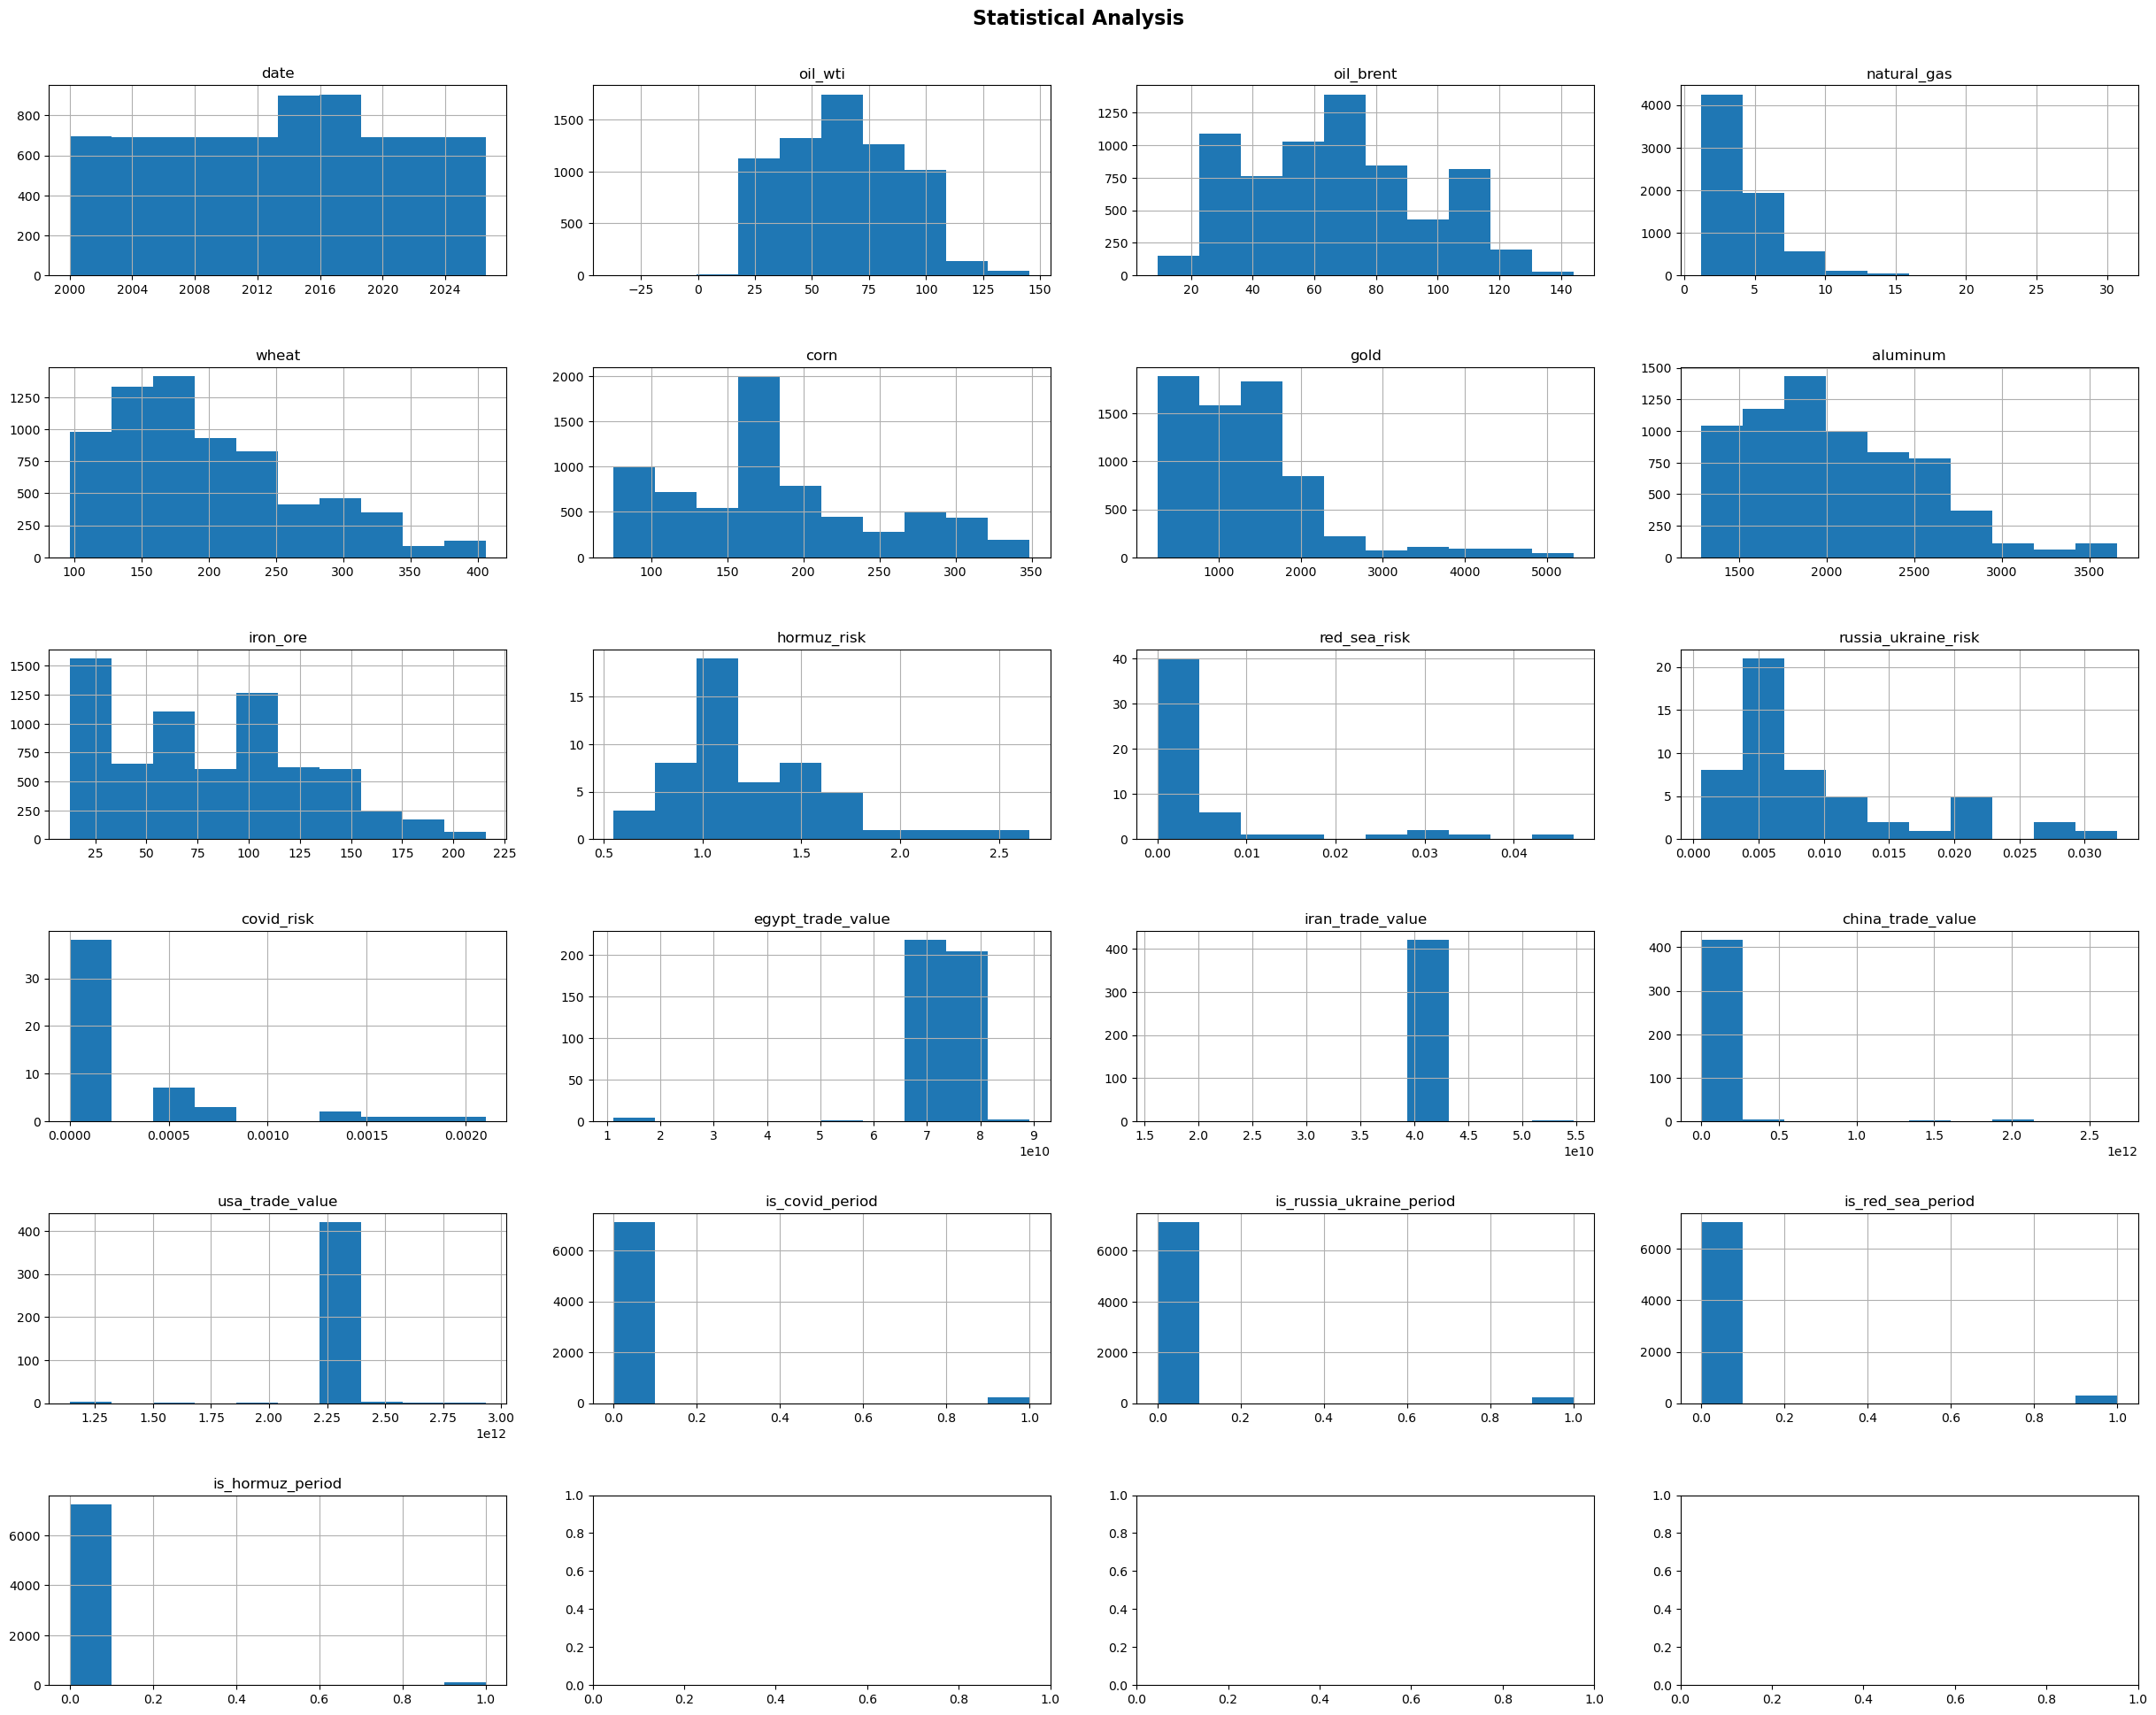

In [37]:
n_col = len(master.columns)
n_cols= int(np.sqrt(n_col))

fig,ax = plt.subplots(6,n_cols,figsize=(25,20))
ax = ax.flatten()
plt.suptitle("Statistical Analysis", fontsize=16, fontweight= "bold")

for i , name in enumerate(master):
    master[name].hist(ax=ax[i])
    ax[i].set_title(name)

plt.tight_layout(pad=3.0)
plt.savefig("charts/commodities_histograms.png")
plt.show()

### 5.1 Statistical Analysis — Distribution Summary

**Commodities — now correctly showing real price ranges**:
- `oil_wti` and `oil_brent` show realistic $0–150/barrel ranges, right-skewed as expected for commodity prices.
- `gold` now spans roughly $250–5,000+, correctly reflecting real historical gold prices — including the recent surge above $4,000.
- `wheat`, `corn`, `aluminum`, `iron_ore` all show plausible, right-skewed distributions consistent with real commodity price behavior.
- `natural_gas` is heavily right-skewed, with most values clustered low and a long tail — consistent with periodic price spikes during supply shocks.

**GDELT risk indicators (`hormuz_risk`, `red_sea_risk`, `russia_ukraine_risk`, `covid_risk`)** are heavily concentrated near zero, with very few non-zero observations. This is expected given GDELT's DOC API only provides roughly a 3-month historical lookback — the vast majority of the 25-year date range simply has no GDELT coverage at all, not a genuinely "calm" signal.

**Trade value columns (`egypt_trade_value`, `iran_trade_value`, `china_trade_value`, `usa_trade_value`)** show a bimodal-looking pattern — a small cluster near zero and a separate, tighter cluster elsewhere. This reflects the year-based merge: each yearly Comtrade value repeats across ~365 daily rows, so the histogram is really showing ~25 distinct yearly values, weighted by day count, not continuous daily variation.

**`date`** is roughly uniform across the 2000–2026 range, as expected for daily time-series data.

**Next steps:** with distributions now confirmed sensible across all columns, proceed to correlation analysis and the yearly trend view, followed by target construction (% change in oil price, forward window).

<div style = background-color:#EDEAE5;padding:10px 15px;border-radius:6px;">
<h3 style = "color:#1F3864;text-align:center;margin:0">5.2 Correlation Analysis </h3>
</div>

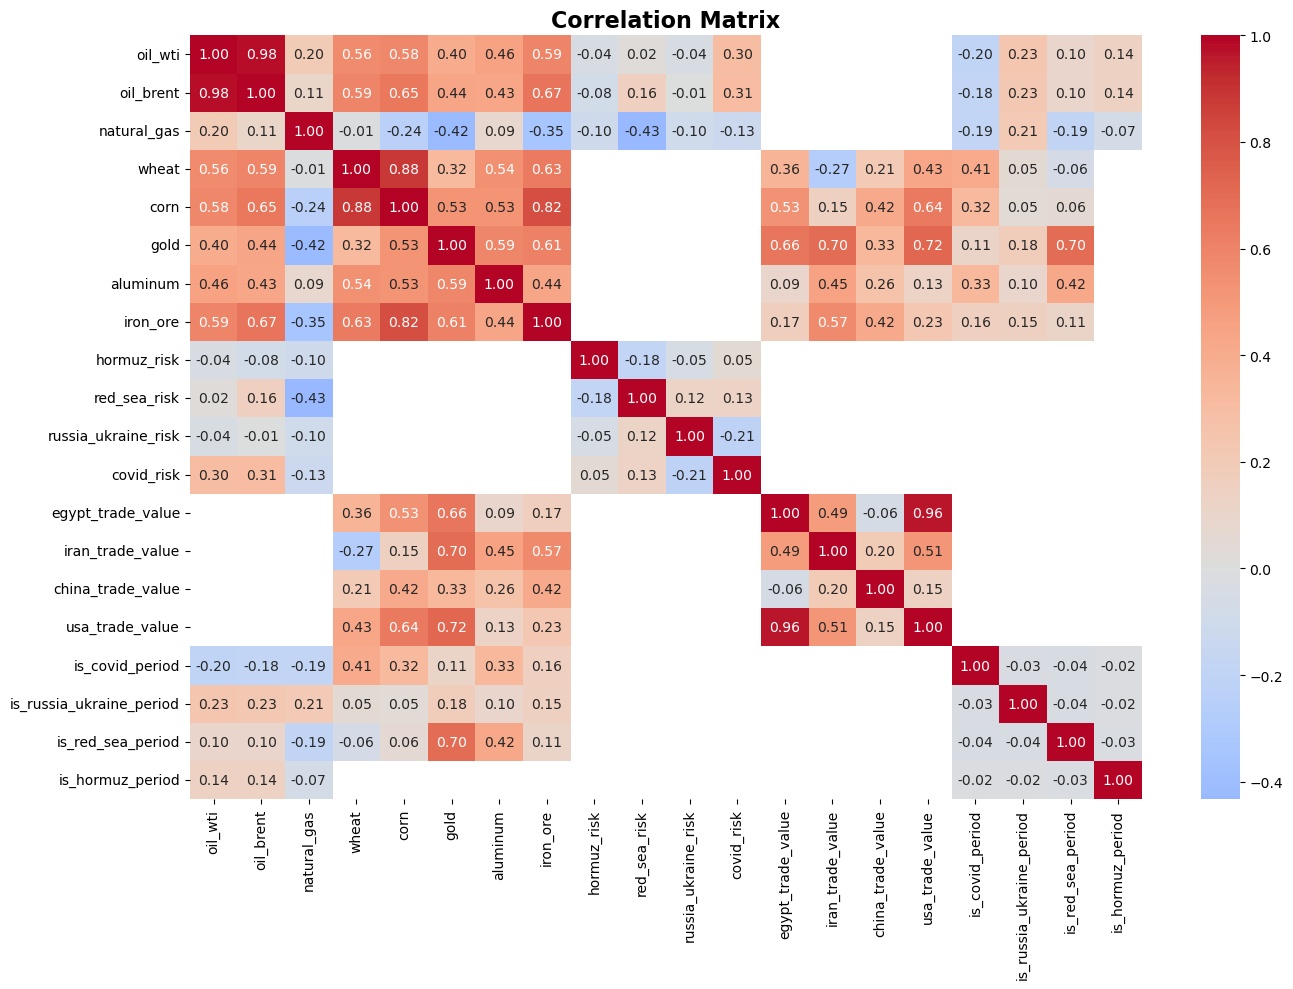

In [38]:
correlation = master.select_dtypes(include="number").corr()
plt.figure(figsize=(14, 10))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix", fontsize=16, fontweight= "bold")
plt.tight_layout()
plt.savefig("charts/correlation_matrix.png")
plt.show()

### 5.2 Correlation Matrix — Key Findings

**Very strong relationships:**
- `oil_wti` and `oil_brent`: **0.98** — expected, since both track the same underlying global oil market, just different benchmark grades.
- `corn` and `iron_ore`: **0.82**, `egypt_trade_value` and `usa_trade_value`: **0.96** — likely reflects broad, shared macro trends (global growth, inflation) over the 25-year window rather than a direct causal link between these specific pairs. Worth treating as a multicollinearity risk for linear models later, though tree-based models (your usual winners) handle this natively.

**Commodities broadly move together:** wheat, corn, gold, aluminum, and iron_ore all show moderate-to-strong positive correlations with each other (0.3–0.9 range) — consistent with a general "commodity supercycle" effect, where broad economic conditions push most raw materials in the same direction simultaneously.

**`natural_gas` stands out as the exception** — negatively correlated with gold (-0.42), iron_ore (-0.35), and red_sea_risk (-0.43), unlike every other commodity. Worth investigating further; natural gas often behaves differently from other commodities due to its own supply-specific dynamics (pipeline capacity, storage, regional pricing) rather than tracking the general commodity trend.

**GDELT risk columns show weak correlations with oil** (`hormuz_risk` vs `oil_wti`: -0.04, `red_sea_risk` vs `oil_wti`: 0.02) — **but this is likely not meaningful yet**, given GDELT's real coverage is only ~53 days out of 7,348. A correlation computed on that few data points is inherently noisy and shouldn't be read as "GDELT has no relationship with oil prices."

**Several cells are blank (undefined), not just weak — this is a real, explainable pattern:** every GDELT risk column shows blank correlations against the monthly commodities and yearly trade values. This happens because correlation requires *variation* in both columns over their overlapping period — but within GDELT's narrow ~53-day non-null window, the forward-filled monthly/yearly values are often constant (no new report arrives in such a short span), making correlation mathematically undefined rather than just small.

**Modeling implication:** GDELT's limited historical window means its true predictive relationship with oil price can't be reliably assessed from this full-history correlation matrix — its value will need to be evaluated specifically within the recent period it actually covers, once the target column and train/test split are built.

<div style="background-color:#EDCC80; padding:15px; border-radius:8px;">
<h2 style="color:#1F3864; text-align:center; margin:0;">6. Data Preprocessing </h2>
</div>

<div style = background-color:#EDEAE5;padding:10px 15px;border-radius:6px;">
<h3 style = "color:#1F3864;text-align:center;margin:0">6.1 Missing Values </h3>
</div>

In [39]:
master.isna().sum()

date                           0
oil_wti                      688
oil_brent                    606
natural_gas                  464
wheat                        438
corn                         438
gold                         589
aluminum                     438
iron_ore                     438
hormuz_risk                 7295
red_sea_risk                7295
russia_ukraine_risk         7295
covid_risk                  7295
egypt_trade_value           6918
iran_trade_value            6918
china_trade_value           6918
usa_trade_value             6918
is_covid_period                0
is_russia_ukraine_period       0
is_red_sea_period              0
is_hormuz_period               0
dtype: int64

In [40]:
master["oil_wti"] = master["oil_wti"].ffill()
master["oil_brent"] = master["oil_brent"].ffill()
master["natural_gas"] = master["natural_gas"].ffill()
master["wheat"] = master["wheat"].ffill()
master["corn"] = master["corn"].ffill()
master["gold"] = master["gold"].ffill()
master["aluminum"] = master["aluminum"].ffill()
master["iron_ore"] = master["iron_ore"].ffill()

In [41]:
master.isna().sum()

date                           0
oil_wti                        1
oil_brent                      1
natural_gas                    1
wheat                         21
corn                          21
gold                         172
aluminum                      21
iron_ore                      21
hormuz_risk                 7295
red_sea_risk                7295
russia_ukraine_risk         7295
covid_risk                  7295
egypt_trade_value           6918
iran_trade_value            6918
china_trade_value           6918
usa_trade_value             6918
is_covid_period                0
is_russia_ukraine_period       0
is_red_sea_period              0
is_hormuz_period               0
dtype: int64

In [42]:
master = master.dropna(subset=["oil_wti", "oil_brent", "natural_gas", "wheat", "corn", "gold", "aluminum", "iron_ore"])

In [43]:
master.isna().sum()

date                           0
oil_wti                        0
oil_brent                      0
natural_gas                    0
wheat                          0
corn                           0
gold                           0
aluminum                       0
iron_ore                       0
hormuz_risk                 7123
red_sea_risk                7123
russia_ukraine_risk         7123
covid_risk                  7123
egypt_trade_value           6746
iran_trade_value            6746
china_trade_value           6746
usa_trade_value             6746
is_covid_period                0
is_russia_ukraine_period       0
is_red_sea_period              0
is_hormuz_period               0
dtype: int64

<div style = background-color:#EDEAE5;padding:10px 15px;border-radius:6px;">
<h3 style = "color:#1F3864;text-align:center;margin:0">6.2 Checking data type </h3>
</div>

In [44]:
master.dtypes

date                        datetime64[ns]
oil_wti                            float64
oil_brent                          float64
natural_gas                        float64
wheat                              float64
corn                               float64
gold                               float64
aluminum                           float64
iron_ore                           float64
hormuz_risk                        float64
red_sea_risk                       float64
russia_ukraine_risk                float64
covid_risk                         float64
egypt_trade_value                  float64
iran_trade_value                   float64
china_trade_value                  float64
usa_trade_value                    float64
is_covid_period                      int64
is_russia_ukraine_period             int64
is_red_sea_period                    int64
is_hormuz_period                     int64
dtype: object

## No need to column trasforming 

<div style = background-color:#EDEAE5;padding:10px 15px;border-radius:6px;">
<h3 style = "color:#1F3864;text-align:center;margin:0">6.3 Defining X & Y  </h3> 
</div>

In [45]:
master = master.sort_values("date")
split_rate = 0.8
x = master.drop(columns=["oil_wti","date","hormuz_risk",
                        "red_sea_risk","russia_ukraine_risk","covid_risk",
                        "egypt_trade_value","iran_trade_value","china_trade_value",
                        "usa_trade_value"])
y = master["oil_wti"]

In [46]:
split = int(len(master)*split_rate)
x_train = x.iloc[:split]
x_test = x.iloc[split:]
y_train = y.iloc[:split]
y_test = y.iloc[split:]

<div style="background-color:#EDCC80; padding:15px; border-radius:8px;">
<h2 style="color:#1F3864; text-align:center; margin:0;">7. Model </h2>
</div>

In [47]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [48]:
models = {
    "LinearRegression":LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(random_state=42),
    "XGBRegressor": XGBRegressor(random_state=42),
    "LGBMRegressor": LGBMRegressor(random_state=42)}

In [62]:
result = []
best_pipe = None
best_model = None
best_r2 = -999
meanabsoluteerror = 0
meansquarederror = 0

In [65]:
for name , model in models.items():
    pipe = Pipeline([
        ("scaler",StandardScaler()),
        ("Model",model)])
    pipe.fit(x_train,y_train)
    print(f"Name:{name},Score: {pipe.score(x_train,y_train)}")
    y_pred = pipe.predict(x_test)

    r2 = r2_score(y_test,y_pred)
    mae = mean_absolute_error(y_test,y_pred)
    mse = mean_squared_error(y_test,y_pred)

    print(name)
    print(f"R2 SCORE : {r2}")
    print(f"mean_absolute_error: {mae} ")
    print(f"mean_squared_error: {mse}")
        
    if r2 > best_r2:
        best_pipe = pipe
        best_model = model
        best_r2 = r2
        meanabsoluteerror = mae
        meansquarederror = mse

Name:LinearRegression,Score: 0.9799629306177253
LinearRegression
R2 SCORE : 0.9062253025672977
mean_absolute_error: 3.3731836071095973 
mean_squared_error: 17.025688839204378
Name:RandomForestRegressor,Score: 0.9995929318772682
RandomForestRegressor
R2 SCORE : 0.76206845349019
mean_absolute_error: 5.573565181058501 
mean_squared_error: 43.198736832117056
Name:XGBRegressor,Score: 0.9992658430510489
XGBRegressor
R2 SCORE : 0.7522714182001178
mean_absolute_error: 5.81226426371625 
mean_squared_error: 44.97748183436226
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000281 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1466
[LightGBM] [Info] Number of data points in the train set: 5740, number of used features: 8
[LightGBM] [Info] Start training from score 60.488659
Name:LGBMRegressor,Score: 0.9975679272776673
LGBMRegressor
R2 SCORE : 0.8474054825691834
mean_absolute_error: 4.2937204324039016 
mean_squ

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [50]:
print(y_train.min(), y_train.max())
print(y_test.min(), y_test.max())

-36.98 145.31
52.16 123.64


In [51]:
x_train.isna().sum()

oil_brent                   0
natural_gas                 0
wheat                       0
corn                        0
gold                        0
aluminum                    0
iron_ore                    0
is_covid_period             0
is_russia_ukraine_period    0
is_red_sea_period           0
is_hormuz_period            0
dtype: int64

<div style="background-color:#EDCC80; padding:15px; border-radius:8px;">
<h2 style="color:#1F3864; text-align:center; margin:0;">8. Model Result Analysis </h2>
</div>

In [52]:
pipe = Pipeline([
        ("scaler",StandardScaler()),
        ("Model",LinearRegression())])
pipe.fit(x_train,y_train)
y_best_pred = pipe.predict(x_test)

<div style = background-color:#EDEAE5;padding:10px 15px;border-radius:6px;">
<h3 style = "color:#1F3864;text-align:center;margin:0">8.1 Residual Plot  </h3> 
</div>

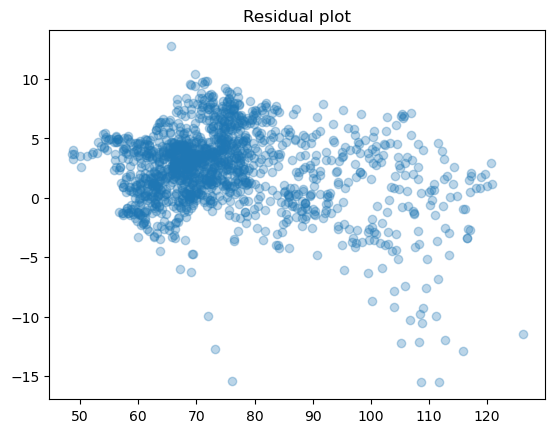

In [78]:
res = y_test - y_best_pred
plt.scatter(y_best_pred,res,alpha=0.3)
plt.title("Residual plot")
plt.savefig("Residualplot.png", dpi=300, bbox_inches="tight")
plt.show()

<div style = background-color:#EDEAE5;padding:10px 15px;border-radius:6px;">
<h3 style = "color:#1F3864;text-align:center;margin:0">8.2 Actual VS Predicted  </h3> 
</div>

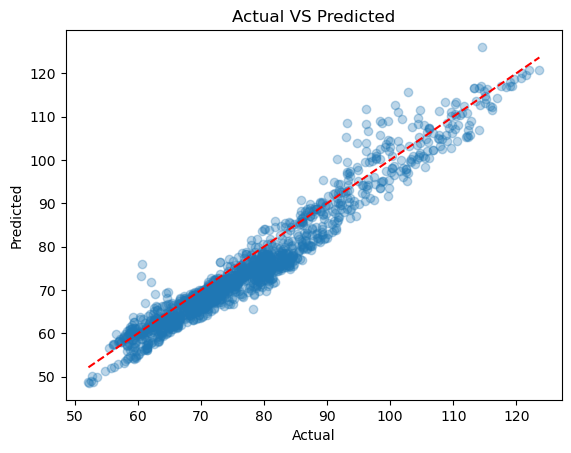

In [79]:
plt.scatter(y_test,y_best_pred,alpha=0.3)
plt.plot([y_test.min(),y_test.max()],
        [y_test.min(),y_test.max()],"r--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual VS Predicted")
plt.savefig("Actual Vs Predicted.png", dpi=300, bbox_inches="tight")
plt.show()

<div style = background-color:#EDEAE5;padding:10px 15px;border-radius:6px;">
<h3 style = "color:#1F3864;text-align:center;margin:0">8.3  Feature Importance  </h3> 
</div>

In [71]:
feat_imp = pd.Series(best_model.coef_,index=x_train.columns)
feat_imp = feat_imp.reindex(feat_imp.abs().sort_values(ascending=False).index)

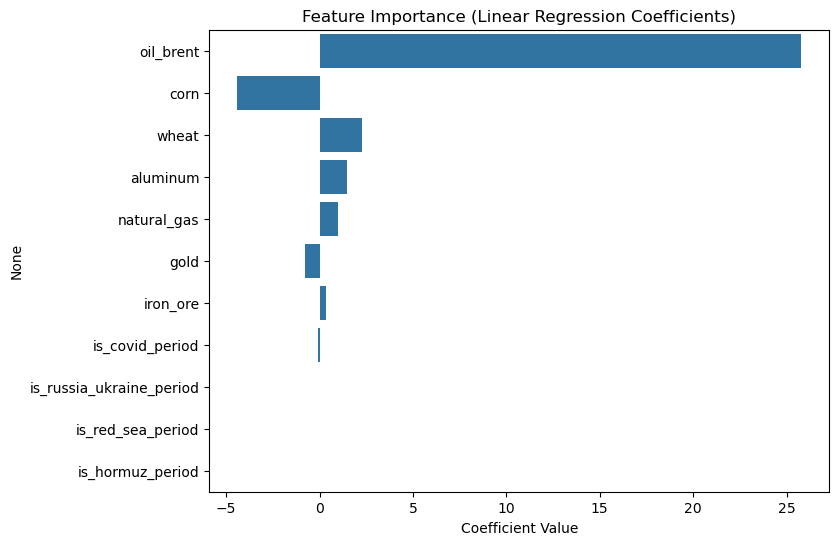

In [80]:
plt.figure(figsize=(8, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.savefig("Feature Importance.png", dpi=300, bbox_inches="tight")
plt.show()

<div style = background-color:#EDEAE5;padding:10px 15px;border-radius:6px;">
<h3 style = "color:#1F3864;text-align:center;margin:0">8.4  Shap  </h3> 
</div>

In [73]:
import shap

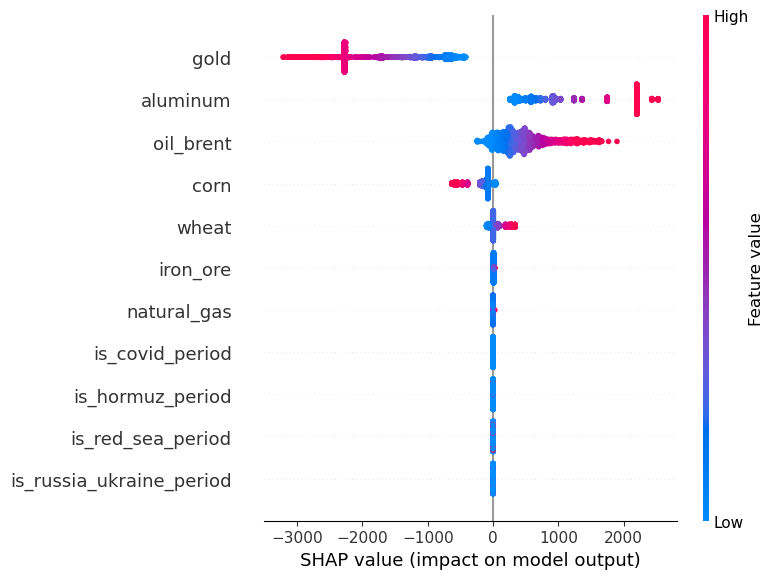

<Figure size 640x480 with 0 Axes>

In [82]:
explainer = shap.Explainer(best_model,x_train)
shap_values = explainer(x_test)
shap.summary_plot(shap_values,x_test)
plt.savefig("shap.png", dpi=300, bbox_inches="tight")